# Analyse Klebsiella pneumoniae intra-genome variation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file ="/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/pangenome_analysis/gpa_reference_batch_summary_20260402_182612.tsv"

df = pd.read_csv(file, sep="\t")
df.head()


,directory_leaf,modality,resolution,n_samples,n_gpa_samples_raw,n_kpsc_samples,n_unique_sublineages,sublineages_complete,n_unique_clonal_groups,clonal_groups_complete,...,norway_max_mean_jaccard,norway_min_shared_genes,norway_mean_shared_genes,norway_max_shared_genes,norway_min_shared_pct,norway_mean_shared_pct,norway_max_shared_pct,norway_top_genome_ids,norway_top_mean_jaccards,status
0,CG17_all,gpa,0.3,1144,1164,1144,1,False,1,True,...,0.15,4282.78,4241.39,4203.87,93.53,92.63,91.81,"['SAMEA114492509', 'SAMEA111533203', 'SAMEA894...","[0.1214854263776187, 0.1390066275565266, 0.151...",ok
1,CG101_all,gpa,0.3,1561,1561,1561,1,False,1,True,...,0.15,4294.34,4279.68,4269.20,92.34,92.03,91.80,"['SAMEA113605573', 'SAMEA113605418', 'SAMEA894...","[0.14229618854931594, 0.14928306095223115, 0.1...",ok
2,CG16_all,gpa,0.3,1753,1753,1753,1,False,1,True,...,0.10,4405.57,4405.57,4405.57,94.74,94.74,94.74,['SAMEA8948693'],[0.0998932520719497],ok
3,CG231_all,gpa,0.3,1028,1055,1028,1,False,1,True,...,0.13,4295.47,4279.53,4266.72,93.85,93.50,93.22,"['SAMEA8948662', 'SAMEA8948402', 'SAMEA8948510']","[0.11583029393718053, 0.12322880717765303, 0.1...",ok
4,CG14_all,gpa,0.3,2232,2232,2232,1,False,1,True,...,0.18,4298.29,4262.64,4176.31,92.49,91.72,89.86,"['SAMEA113605363', 'SAMEA113605930', 'SAMEA894...","[0.13977314860009818, 0.14086994201844052, 0.1...",ok


In [2]:
# print the list of columns names as a list, one per line
for col in df.columns:
    print(col)


directory_leaf
modality
resolution
n_samples
n_gpa_samples_raw
n_kpsc_samples
n_unique_sublineages
sublineages_complete
n_unique_clonal_groups
clonal_groups_complete
species
strain
samples_in_strain
run_classification
n_leiden_clusters
k_neighbors
min_cluster_size
subclusters_before_merge
genomes_reassigned
subclusters_after_merge
global_medoid_jaccard_mean
own_cluster_medoid_jaccard_mean
gain_jaccard_b_minus_c
gain_similarity
mean_features_per_genome
global_medoid_shared_features_est
own_cluster_medoid_shared_features_est
gain_shared_features_est
global_medoid_shared_features_pct
own_cluster_medoid_shared_features_pct
gain_shared_features_pct_points
mean_genome_size
sd_genome_size
mean_core_genes
sd_core_genes
mean_softcore_genes
sd_softcore_genes
mean_shell_genes
sd_shell_genes
mean_cloud_genes
sd_cloud_genes
global_ref_in_gpa
global_ref_mean_jaccard_to_others
global_ref_mean_shared_genes
global_ref_mean_shared_pct
global_ref_sd_shared_genes
global_ref_divergent_genes_mean
n_refseq_g

In [3]:
# Get unique strain values
strains = df['run_classification'].unique()
print(strains)

# Slice the df to run_classification is in ["sublineage", "sublineage_split", "rare_sublineage  "]
df_sublineage = df[df['run_classification'].isin(["sublineage", "sublineage-split", "rare-lineage"])]

# Get a sl_sub_table of strain, n_kpsc_samples, n_unique_sublineages, mean_genome_size, sd_genome_size, mean_core_genes, sd_core_genes, mean_softcore_genes, sd_softcore_genes, mean_shell_genes, sd_shell_genes, mean_cloud_genes, sd_cloud_genes
sl_sub_table = df_sublineage[['strain', 'n_kpsc_samples', 'samples_in_strain', 'n_unique_sublineages', 'mean_genome_size', 'sd_genome_size', 'mean_core_genes', 'sd_core_genes', 'mean_softcore_genes', 'sd_softcore_genes', 'mean_shell_genes', 'sd_shell_genes', 'mean_cloud_genes', 'sd_cloud_genes']]


sl_sub_table.loc[sl_sub_table['strain'] == "Klebsiella pneumoniae", 'samples_in_strain'] = sl_sub_table.loc[sl_sub_table['strain'] == "Klebsiella pneumoniae", 'n_kpsc_samples']



<StringArray>
[      'clonal-group', 'clonal-group-split',     'non-kp-species',
         'sublineage',   'sublineage-other',   'sublineage-split',
       'rare-lineage']
Length: 7, dtype: str


In [4]:
# If we have two rows with 1 unique sublineage and same strain, then keep the row with the highest n_kpsc_samples or the first if they are the same
sl_sub_table = sl_sub_table.groupby(['strain', 'n_unique_sublineages']).apply(lambda x: x.loc[x['n_kpsc_samples'].idxmax()])

# Order the rows by n_unique_sublineages ascending, and then by samples_in_strain descending
sl_sub_table = sl_sub_table.sort_values(by=['n_unique_sublineages', 'samples_in_strain'], ascending=[True, False])

# Ungroup the sl_sub_table - keep the index
sl_sub_table = sl_sub_table.reset_index(drop=False)

# Relabel repeated Klebsiella pneumoniae rows as K.p rare 1..n
kp_mask = sl_sub_table['strain'].eq('Klebsiella pneumoniae')
kp_n = int(kp_mask.sum())
sl_sub_table.loc[kp_mask, 'strain'] = [f'K.p rare {i}' for i in range(1, kp_n + 1)]

# Print the sl_sub_table
display(sl_sub_table)




,strain,n_unique_sublineages,n_kpsc_samples,samples_in_strain,mean_genome_size,sd_genome_size,mean_core_genes,sd_core_genes,mean_softcore_genes,sd_softcore_genes,mean_shell_genes,sd_shell_genes,mean_cloud_genes,sd_cloud_genes
0,SL258,1,2500.0,16229.0,4721.60,126.79,3558.73,8.28,367.99,11.81,656.80,115.03,138.08,107.56
1,SL147,1,2548.0,5096.0,4691.16,151.16,3841.20,8.47,186.59,8.43,536.11,169.00,127.26,86.26
2,SL17,1,4630.0,4630.0,4563.32,144.95,3735.34,8.41,192.99,7.73,410.31,114.21,224.67,101.13
3,SL307,1,2225.0,4449.0,4590.19,132.83,3936.84,8.61,131.12,6.47,414.25,84.78,107.98,71.16
4,SL15,1,1824.0,3647.0,4620.74,146.88,3655.59,9.15,369.12,14.57,432.01,84.12,164.02,110.84
5,SL14,1,2521.0,2521.0,4625.80,140.37,3780.55,8.67,212.53,9.98,489.10,173.35,143.61,106.38
6,SL37,1,1871.0,1871.0,4525.13,145.19,3763.10,8.48,162.38,6.04,360.41,57.56,239.24,114.87
7,SL45,1,1803.0,1803.0,4563.35,136.15,3808.11,9.40,210.60,7.98,387.56,130.61,157.09,88.38
8,SL101,1,1610.0,1610.0,4639.75,117.49,3867.76,7.26,153.74,11.80,509.31,114.89,108.94,73.07
9,SL231,1,1049.0,1049.0,4571.54,102.94,3917.26,8.02,205.90,16.33,338.71,79.40,109.67,118.94


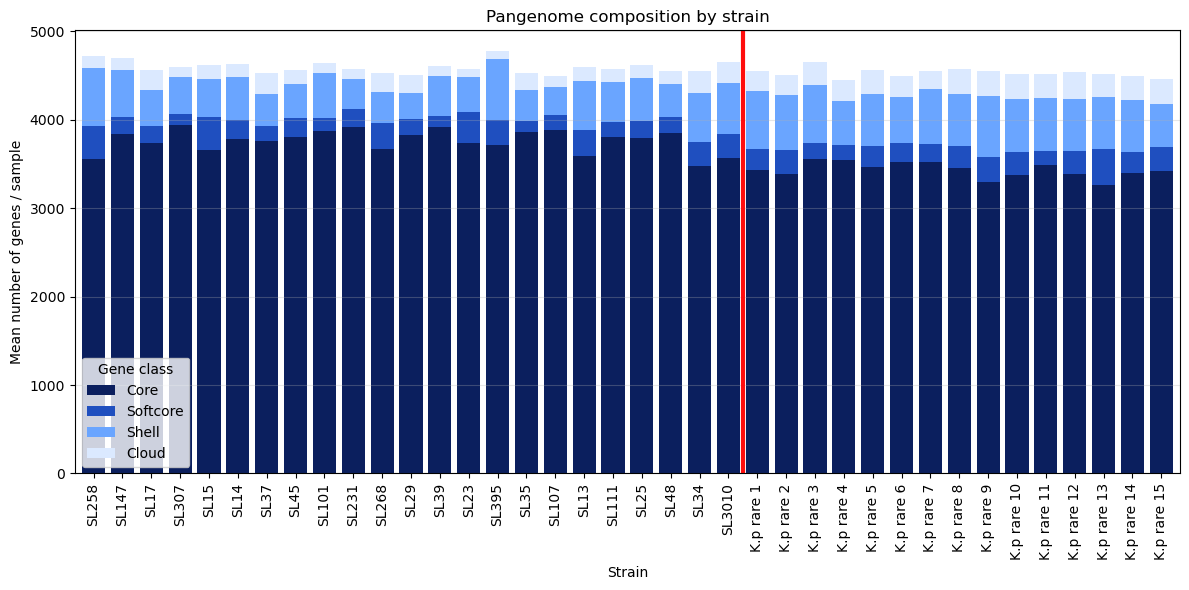

In [5]:
# Plot 2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Stacked cumulative columns for the same strains in sl_sub_table
sl_sub_table.plot(
    kind='bar',
    x='strain',
    y=['mean_core_genes', 'mean_softcore_genes', 'mean_shell_genes', 'mean_cloud_genes'],
    stacked=True,
    color=['#0b1f5e', '#1f4fbf', '#6aa5ff', '#dbe9ff'],
    width=0.8,
    ax=ax
)

# Draw separator between n_unique_sublineages == 1 and > 1 groups
n_one = int((sl_sub_table['n_unique_sublineages'] == 1).sum())
if 0 < n_one < len(sl_sub_table):
    ax.axvline(x=n_one - 0.5, color='red', linewidth=3, alpha=0.95)

ax.set_title('Pangenome composition by strain')
ax.set_ylabel('Mean number of genes / sample')
ax.set_xlabel('Strain')
ax.grid(axis='y', alpha=0.3)

# Keep legend tied to stacked bars (exclude separator line)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles[:4], ['Core', 'Softcore', 'Shell', 'Cloud'], title='Gene class')

fig.tight_layout()


### Requested test: each `n_unique_sublineages == 1` strain vs aggregate of `n_unique_sublineages > 1`

This follows the requested setup exactly:

- Target set: each row where `n_unique_sublineages == 1` (tested one at a time)
- Comparator set: all rows where `n_unique_sublineages > 1` (same comparator for every test)
- Comparator mean: weighted by `samples_in_strain` to represent all comparator samples
- SEs: computed from summary-level variances of means (`sd_genome_size^2 / samples_in_strain`)
- Multiplicity correction: Bonferroni using `m = number of tests = count(n_unique_sublineages == 1)`

Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (mean_genome_size): 4528.10


,strain,samples_in_strain,target_mean_genome_size,rest_mean_genome_size,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,4721.60,4528.102839,193.497161,0.995266,1.593330,121.441991,0.000000e+00,0.000000e+00,190.374234,196.620087
1,SL147,5096,4691.16,4528.102839,163.057161,2.117494,2.455998,66.391404,0.000000e+00,0.000000e+00,158.243404,167.870917
2,SL395,851,4770.30,4528.102839,242.197161,4.985276,5.138202,47.136554,0.000000e+00,0.000000e+00,232.126284,252.268038
3,SL101,1610,4639.75,4528.102839,111.647161,2.928114,3.181509,35.092522,8.765663e-270,2.016103e-268,105.411404,117.882918
4,SL15,3647,4620.74,4528.102839,92.637161,2.432175,2.731963,33.908647,4.967565e-252,1.142540e-250,87.282514,97.991808
5,SL14,2521,4625.80,4528.102839,97.697161,2.795683,3.060063,31.926516,1.144618e-223,2.632622e-222,91.699436,103.694885
6,SL307,4449,4590.19,4528.102839,62.087161,1.991430,2.348178,26.440572,4.683535e-154,1.077213e-152,57.484732,66.689589
7,SL39,886,4611.08,4528.102839,82.977161,3.840991,4.037494,20.551647,7.439603e-94,1.711109e-92,75.063671,90.890650
8,SL25,590,4616.15,4528.102839,88.047161,4.930029,5.084618,17.316378,3.539476e-67,8.140796e-66,78.081310,98.013011
9,SL3010,502,4646.94,4528.102839,118.837161,7.002343,7.112029,16.709318,1.121095e-62,2.578518e-61,104.897583,132.776738


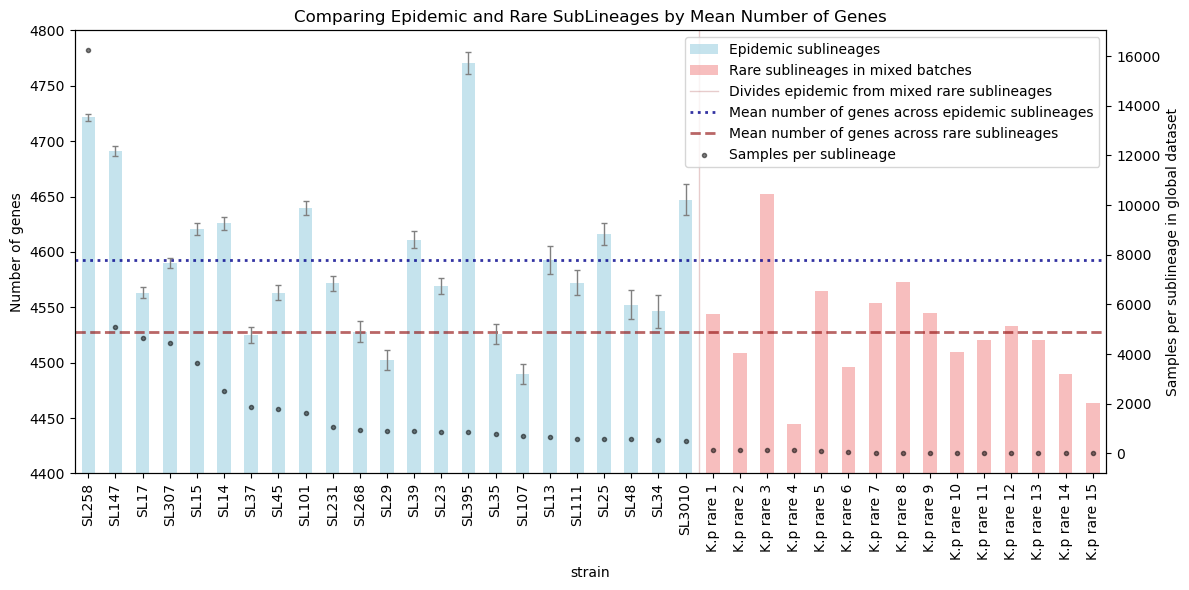

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from math import erfc, sqrt


def _mean_sd_columns(metric):
    return f'mean_{metric}', f'sd_{metric}'


def sublineage_vs_rare_lineage_stats(
    sl_sub_table,
    metric='genome_size',
    *,
    show_table=True,
):
    """Compute per-strain tests: n_unique_sublineages==1 vs pooled >1 group.

    Returns (out_df, rest_mean, rest_var).
    CI columns are on the difference scale: (target_mean - rest_mean).
    """
    mean_col, sd_col = _mean_sd_columns(metric)
    cols = ['strain', 'n_unique_sublineages', mean_col, sd_col, 'samples_in_strain']
    missing = [c for c in cols if c not in sl_sub_table.columns]
    if missing:
        raise KeyError(f'sl_sub_table missing columns: {missing}')

    req_df = sl_sub_table[cols].copy()
    req_df = req_df.dropna(subset=cols)
    req_df = req_df[(req_df['samples_in_strain'] > 1) & (req_df[sd_col] > 0)].copy()
    req_df['var_mean'] = (req_df[sd_col] ** 2) / req_df['samples_in_strain']

    targets = req_df[req_df['n_unique_sublineages'] == 1].copy()
    rest = req_df[req_df['n_unique_sublineages'] > 1].copy()

    if targets.empty:
        print('No target rows where n_unique_sublineages == 1 after filtering.')
        return None, None, None
    if rest.empty:
        print('No comparator rows where n_unique_sublineages > 1 after filtering.')
        return None, None, None

    rest_weights = rest['samples_in_strain'].to_numpy(dtype=float)
    rest_alpha = rest_weights / rest_weights.sum()
    rest_mean = float(np.sum(rest_alpha * rest[mean_col].to_numpy(dtype=float)))
    rest_var = float(np.sum((rest_alpha ** 2) * rest['var_mean'].to_numpy(dtype=float)))

    target_mean_key = f'target_mean_{metric}'
    rest_mean_key = f'rest_mean_{metric}'

    out = []
    z_crit = 1.96
    for _, row in targets.iterrows():
        target_mean = float(row[mean_col])
        target_var = float(row['var_mean'])
        diff = target_mean - rest_mean
        se_diff = float(np.sqrt(target_var + rest_var))

        if se_diff <= 0 or np.isnan(se_diff):
            z_stat = np.nan
            p_raw = np.nan
            ci_low = np.nan
            ci_high = np.nan
        else:
            z_stat = diff / se_diff
            p_raw = erfc(abs(z_stat) / sqrt(2.0))
            ci_low = diff - z_crit * se_diff
            ci_high = diff + z_crit * se_diff

        out.append({
            'strain': row['strain'],
            'n_unique_sublineages': int(row['n_unique_sublineages']),
            'samples_in_strain': int(row['samples_in_strain']),
            target_mean_key: target_mean,
            rest_mean_key: rest_mean,
            'estimate_target_minus_rest': diff,
            'se_target_mean': float(np.sqrt(target_var)),
            'se_diff': se_diff,
            'z_stat': z_stat,
            'p_raw': p_raw,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

    out_df = pd.DataFrame(out)
    m_tests = len(out_df)
    out_df['p_bonferroni_m'] = np.minimum(out_df['p_raw'] * m_tests, 1.0)
    out_df = out_df.sort_values('p_bonferroni_m').reset_index(drop=True)

    print(f'Number of tests (m): {m_tests}')
    print(f'Comparator rows (n_unique_sublineages > 1): {len(rest)}')
    print(f'Comparator weighted mean ({mean_col}): {rest_mean:.2f}')

    if show_table:
        display_cols = [
            'strain', 'samples_in_strain', target_mean_key, rest_mean_key,
            'estimate_target_minus_rest', 'se_target_mean', 'se_diff', 'z_stat',
            'p_raw', 'p_bonferroni_m', 'ci_low', 'ci_high'
        ]
        display(out_df[display_cols])

    return out_df, rest_mean, rest_var


def sublineage_vs_rare_lineage_plot(
    sl_sub_table,
    out_df,
    rest_mean,
    *,
    metric='genome_size',
    ylabel='Number of genes',
    title='Comparing Epidemic and Rare SubLineages by Mean Number of Genes',
    ylim=(4400, 4800),
):
    """Plot in Plot-1 style with CI error bars from out_df."""
    mean_col = f'mean_{metric}'
    target_mean_col = f'target_mean_{metric}'

    required_sl_sub_table = ['strain', 'n_unique_sublineages', 'samples_in_strain', mean_col]
    missing_sl_sub_table = [c for c in required_sl_sub_table if c not in sl_sub_table.columns]
    if missing_sl_sub_table:
        raise KeyError(f'sl_sub_table missing columns: {missing_sl_sub_table}')

    required_out = ['strain', target_mean_col, 'ci_low', 'ci_high']
    missing_out = [c for c in required_out if c not in out_df.columns]
    if missing_out:
        raise KeyError(f'out_df missing columns: {missing_out}')

    plot_df = sl_sub_table.copy().reset_index(drop=True)

    epidemic_df = plot_df[plot_df['n_unique_sublineages'] == 1]
    epidemic_mean = float(epidemic_df[mean_col].mean()) if not epidemic_df.empty else None

    lower_err = np.full(len(plot_df), np.nan, dtype=float)
    upper_err = np.full(len(plot_df), np.nan, dtype=float)
    ci_lookup = out_df.set_index('strain')[[target_mean_col, 'ci_low', 'ci_high']]

    for i, row in plot_df.iterrows():
        strain = row['strain']
        y = float(row[mean_col])
        if strain in ci_lookup.index:
            ci_low_abs = float(rest_mean) + float(ci_lookup.loc[strain, 'ci_low'])
            ci_high_abs = float(rest_mean) + float(ci_lookup.loc[strain, 'ci_high'])
            lower_err[i] = max(0.0, y - ci_low_abs)
            upper_err[i] = max(0.0, ci_high_abs - y)

    fig, ax = plt.subplots(figsize=(12, 6))

    bar_colors = np.where(plot_df['n_unique_sublineages'].to_numpy() > 1, '#f4a3a3', 'lightblue')
    plot_df.plot(
        kind='bar',
        x='strain',
        y=mean_col,
        legend=False,
        color=bar_colors.tolist(),
        alpha=0.7,
        ax=ax,
    )

    x = np.arange(len(plot_df), dtype=float)
    y = plot_df[mean_col].to_numpy(dtype=float)
    ci_yerr = np.vstack([lower_err, upper_err])
    ax.errorbar(
        x=x,
        y=y,
        yerr=ci_yerr,
        fmt='none',
        ecolor='grey',
        elinewidth=1,
        capsize=2,
        capthick=1,
        zorder=3,
    )

    # Secondary axis: samples_in_strain / n_unique_sublineages
    ax2 = ax.twinx()
    sample_counts = (
        plot_df['samples_in_strain'].to_numpy(dtype=float)
        / plot_df['n_unique_sublineages'].to_numpy(dtype=float)
    )
    ax2.scatter(
        x,
        sample_counts,
        color='black',
        s=9,
        alpha=0.5,
        label='Samples per sublineage',
        zorder=4,
    )
    ax2.set_ylabel('Samples per sublineage in global dataset')

    n_one = int((plot_df['n_unique_sublineages'] == 1).sum())
    if 0 < n_one < len(plot_df):
        ax.axvline(
            x=n_one - 0.5,
            color='darkred',
            linewidth=1,
            alpha=0.2,
            label='Divides epidemic from mixed rare sublineages',
        )
    if epidemic_mean is not None:
        ax.axhline(
            y=float(epidemic_mean),
            color='darkblue',
            linestyle=':',
            linewidth=2,
            alpha=0.8,
            label='Mean number of genes across epidemic sublineages',
        )
        
    if rest_mean is not None:
        ax.axhline(
            y=float(rest_mean),
            color='darkred',
            linestyle='--',
            linewidth=2,
            alpha=0.6,
            label='Mean number of genes across rare sublineages',
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)

    line_handles, line_labels = ax.get_legend_handles_labels()
    line_handles = [h for h, lbl in zip(line_handles, line_labels) if lbl != mean_col]
    ax2_handles, _ = ax2.get_legend_handles_labels()
    bar_handles = [
        Patch(facecolor='lightblue', alpha=0.7, label='Epidemic sublineages'),
        Patch(facecolor='#f4a3a3', alpha=0.7, label='Rare sublineages in mixed batches'),
    ]
    ax.legend(handles=bar_handles + line_handles + ax2_handles, loc='upper right', frameon=True)

    fig.tight_layout()
    return fig, ax


# Backward-compatible wrapper

def sublineage_vs_rare_lineage_comparison(sl_sub_table, metric='genome_size', *, show_plot=True):
    out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_stats(
        sl_sub_table,
        metric=metric,
        show_table=True,
    )
    if show_plot and out_df is not None:
        sublineage_vs_rare_lineage_plot(
            sl_sub_table,
            out_df,
            rest_mean,
            metric=metric,
        )
    return out_df, rest_mean, rest_var


# Example usage
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_stats(
    sl_sub_table,
    metric='genome_size',
    show_table=True,
)
fig, ax = sublineage_vs_rare_lineage_plot(
    sl_sub_table,
    out_df,
    rest_mean,
    metric='genome_size',
)


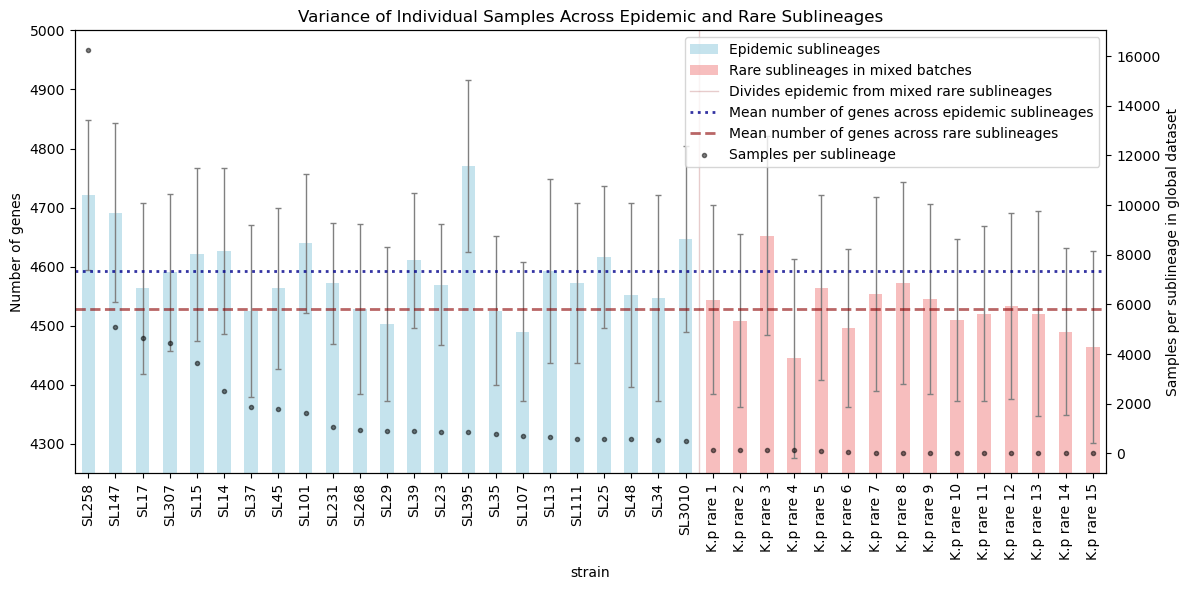

In [8]:
# Plot 3
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = sl_sub_table.copy().reset_index(drop=True)

# Weighted mean for rare sublineages (>1 unique sublineage)
comp = plot_df[
    (plot_df['n_unique_sublineages'] > 1)
    & (plot_df['samples_in_strain'] > 1)
    & (plot_df['sd_genome_size'] > 0)
].copy()
rare_mean = float(
    (comp['mean_genome_size'] * comp['samples_in_strain']).sum() / comp['samples_in_strain'].sum()
) if not comp.empty else None

# Mean for epidemic sublineages (==1 unique sublineage)
epidemic_df = plot_df[plot_df['n_unique_sublineages'] == 1]
epidemic_mean = float(epidemic_df['mean_genome_size'].mean()) if not epidemic_df.empty else None

# Plot bars with separate colors for epidemic vs rare sublineages
bar_colors = np.where(plot_df['n_unique_sublineages'].to_numpy() > 1, '#f4a3a3', 'lightblue')
plot_df.plot(
    kind='bar',
    x='strain',
    y='mean_genome_size',
    yerr='sd_genome_size',
    legend=False,
    capsize=2,
    color=bar_colors.tolist(),
    alpha=0.7,
    ecolor='grey',
    error_kw={'elinewidth': 1, 'ecolor': 'grey'},
    ax=ax,
)

# Secondary axis: samples_in_strain / n_unique_sublineages
ax2 = ax.twinx()
x = np.arange(len(plot_df), dtype=float)
sample_counts = (
    plot_df['samples_in_strain'].to_numpy(dtype=float)
    / plot_df['n_unique_sublineages'].to_numpy(dtype=float)
)
ax2.scatter(
    x,
    sample_counts,
    color='black',
    s=9,
    alpha=0.5,
    label='Samples per sublineage',
    zorder=4,
)
ax2.set_ylabel('Samples per sublineage in global dataset')

# Separator between epidemic and rare groups
n_one = int((plot_df['n_unique_sublineages'] == 1).sum())
if 0 < n_one < len(plot_df):
    ax.axvline(
        x=n_one - 0.5,
        color='darkred',
        linewidth=1,
        alpha=0.2,
        label='Divides epidemic from mixed rare sublineages',
    )

# Reference means
if epidemic_mean is not None:
    ax.axhline(
        y=float(epidemic_mean),
        color='darkblue',
        linestyle=':',
        linewidth=2,
        alpha=0.8,
        label='Mean number of genes across epidemic sublineages',
    )
if rare_mean is not None:
    ax.axhline(
        y=float(rare_mean),
        color='darkred',
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        label='Mean number of genes across rare sublineages',
    )

ax.set_ylabel('Number of genes')
ax.set_title('Variance of Individual Samples Across Epidemic and Rare Sublineages')
ax.set_ylim(4250, 5000)

line_handles, line_labels = ax.get_legend_handles_labels()
line_handles = [h for h, lbl in zip(line_handles, line_labels) if lbl != 'mean_genome_size']
ax2_handles, _ = ax2.get_legend_handles_labels()
bar_handles = [
    Patch(facecolor='lightblue', alpha=0.7, label='Epidemic sublineages'),
    Patch(facecolor='#f4a3a3', alpha=0.7, label='Rare sublineages in mixed batches'),
]
ax.legend(handles=bar_handles + line_handles + ax2_handles, loc='upper right', frameon=True)

fig.tight_layout()

